In [1]:
from imports import *
from information_conditions import Information_Conditions
from base_ecopg import BaseEcologicalPublicGood
from helper_functions import *
from simulation_and_results_functions import *

c:\Users\localuser\AppData\Local\Programs\Python\Python312\Lib\site-packages\matplotlib\quiver.py:695: RuntimeWarning: divide by zero encountered in scalar divide
  length = a * (widthu_per_lenu / (self.scale * self.width))
c:\Users\localuser\AppData\Local\Programs\Python\Python312\Lib\site-packages\matplotlib\quiver.py:695: RuntimeWarning: invalid value encountered in multiply
  length = a * (widthu_per_lenu / (self.scale * self.width))


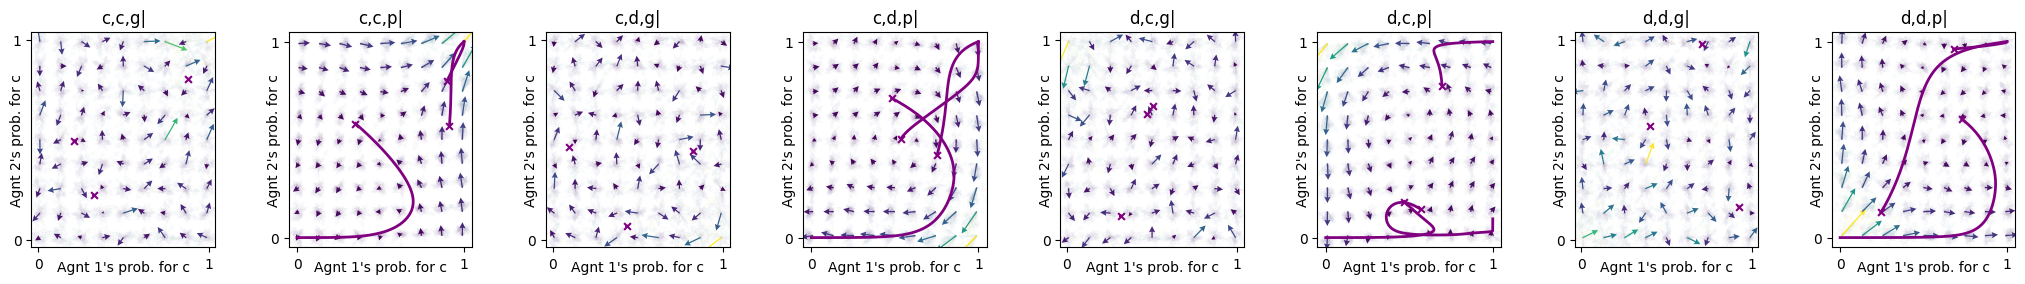

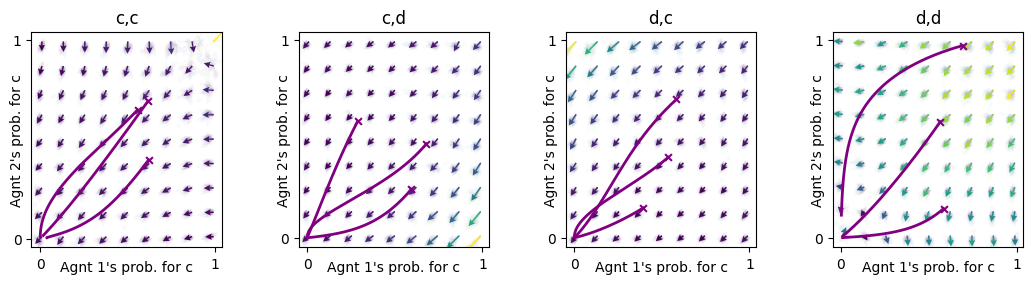

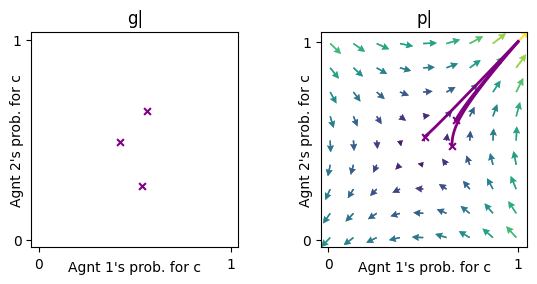

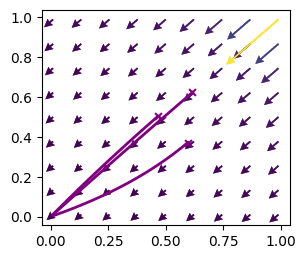

In [3]:
#| export
ecopg = BaseEcologicalPublicGood(m = -6.5)
ecopg_for_random_pts = Information_Conditions(ecopg, mode='complete')
mae = POstratAC(env= ecopg_for_random_pts, learning_rates=0.05, discount_factors=0.9)
mae.random_softmax_strategy()
X_random_list = [mae.random_softmax_strategy() for _ in range(3)]
for mode in ['complete','social', 'ecological','none']:
    #for each information condition get the average policy for the given observation set and plot the flow diagram

    ecopg = BaseEcologicalPublicGood(m = -6.5)

    information_condition_instance = Information_Conditions(ecopg, mode=mode)
    num_observed_states = len(information_condition_instance.Oset[0])
    x, y = ([0], list(range(num_observed_states)), [0]), ([1], list(range(num_observed_states)), [0])
    mae1 = POstratAC(env=information_condition_instance, learning_rates=0.05, discount_factors=0.975)

    ax = fp.plot_strategy_flow(
        mae1,
        x, y, flowarrow_points=np.linspace(0.01, 0.99, 9), NrRandom=32,
        conds=np.array(information_condition_instance.Oset)[0, :num_observed_states],
    )

    for X_for_state_set in X_random_list:
        X_for_observation_set = average_policy_for_given_observation_set(X_for_state_set, information_condition_instance.O)
        xtraj, fixedpointreached = mae1.trajectory(X_for_observation_set, Tmax=10000, tolerance=1e-5)

        fp.plot_trajectories([xtraj], x, y, cols=['purple'], axes = ax)



